# NB-03 · Normalization Diagnostics

**Checks covered**
1. Input stats fit: per-channel `loc` / `scale`, strategy assignment
2. Post-normalization distribution: mean ≈ 0, std ≈ 1 per channel
3. Channels with near-zero variance (scale ≈ 0 → division by zero risk)
4. Extreme outliers after normalization (|z| > 10)
5. **Invertibility**: `||x – denorm(norm(x))||∞ < ε` for both input and output
6. Output stats fit and denormalization roundtrip
7. Phase channels: no log1p applied, scale = π

In [3]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT    = Path("../..").resolve()
DATASET_PATH = Path("/ste/rnd/User/vice_vi/Dataset/clean_dataset")
PARAMS_PATH  = DATASET_PATH / "params" / "params_sig_k5" / "parameters_sig_k5.npy"
DATA_DIR     = DATASET_PATH / "data"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
from tools.logger                      import Logger
from configuration.dataset_config      import DatasetConfiguration, InputConfig, OutputConfig, PatchConfiguration, Representation, SplitRegions
from configuration.training_config     import GaussianConfig
from tools.crop_region                 import CropRegion
from pipelines.dataset_pipeline.load   import PatchDataset
from pipelines.dataset_pipeline.patch  import Patcher
from pipelines.dataset_pipeline.normalize import Stats, StatsComputer, Normalizer

with open(DATA_DIR / "dataset.json") as f:
    layout = json.load(f)

global_crop  = layout["global_crop"]   # [az_start, az_end, rg_start, rg_end]
gc           = CropRegion(*global_crop)

TRAIN_AZ    = (1000, 9120)
PATCH_SIZE  = (64, 64)
STRIDE      = 32
N_GAUSSIANS = 5

logger = Logger(log_dir="/tmp", name="nb03")


## 0 · Build a minimal PatchDataset (no normalization yet)

In [4]:
primary       = np.load(next(DATA_DIR.glob("primary_*.npy")),       mmap_mode='r')
secondaries   = np.load(next(DATA_DIR.glob("secondaries_*.npy")),   mmap_mode='r')
interferograms= np.load(next(DATA_DIR.glob("interferograms_*.npy")), mmap_mode='r')
params_full   = np.load(PARAMS_PATH,                                mmap_mode='r')

az0, az1   = TRAIN_AZ
rg0, rg1   = gc.range_start, gc.range_end

inputs_crop = np.concatenate([
    primary     [np.newaxis, az0:az1, rg0:rg1],
    secondaries [:, az0:az1, rg0:rg1],
    interferograms[:, az0:az1, rg0:rg1],
], axis=0).astype(np.complex64)

params_crop = params_full[:, az0:az1, rg0:rg1].astype(np.float32)

H, W = inputs_crop.shape[1], inputs_crop.shape[2]
patcher = Patcher.build((H, W), PATCH_SIZE, STRIDE)

input_config  = InputConfig(
    use_primary=True,  primary_representation=Representation.MAG_ONLY,
    use_secondaries=True, secondaries_representation=Representation.MAG_ONLY,
    use_interferograms=True, interferograms_representation=Representation.ANGLE_ONLY,
)
output_config = OutputConfig()

dataset_raw = PatchDataset(
    inputs        = inputs_crop,
    gt_parameters = params_crop,
    grid          = patcher,
    input_config  = input_config,
    output_config = output_config,
    split_name    = "train",
    norm_stats    = None,
    n_gaussians   = N_GAUSSIANS,
)
print(f"Dataset length : {len(dataset_raw)} patches")
x0, y0 = dataset_raw[0]
print(f"Input  shape   : {x0.shape}")
print(f"Output shape   : {y0.shape}")

Dataset length : 23529 patches
Input  shape   : (9, 64, 64)
Output shape   : (15, 64, 64)


## 1 · Fit input statistics

In [5]:
n_slaves = secondaries.shape[0]

input_stats_obj = StatsComputer.compute_input_stats(
    dataset     = dataset_raw,
    logger      = logger,
    input_config= input_config,
    n_slaves    = n_slaves,
    max_samples = 2000,
    num_workers = 0,
    batch_size  = 256,
)

stats = input_stats_obj.input_stats
print(f"\nFitted {stats.n_channels} input channels:")
print(f"  {'Ch':>3s}  {'Name':<30s}  {'loc':>10s}  {'scale':>10s}  {'log1p':>6s}")
print("  " + "-" * 65)
for ch in range(stats.n_channels):
    strat = stats.strategies[ch]
    print(f"  {ch:>3d}  {stats.names[ch]:<30s}  {stats.loc[ch]:>10.4f}  {stats.scale[ch]:>10.4f}  {str(strat.apply_log1p):>6s}")

──────────────────────────────────────── [INPUT NORMALIZATION STATISTICS] ─────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Field          ┃ Value                                                    ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Strategy       │ auto-selected per slot-kind (grouped across passes/ifgs) │
│ Samples        │ 2,000 / 23,529                                           │
│ Input channels │ 9                                                        │
└────────────────┴──────────────────────────────────────────────────────────┘

────────────────────────────────────────── [INPUT GROUPING BY SLOT-KIND] ──────────────────────────────────────────

  > Input grouping (2 groups, 9 channels):

  >   pass/mag                 ->   5 ch  [0-4]

  >   ifg/phase                ->   4 ch  [5-8]

──────────────────────────────────────────── [INPUT STATS PER CHANNEL] ────────────────────────────────────────────

┏━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Ch ┃ Slot      ┃ Strategy     ┃ log1p ┃ loc       ┃ scale    ┃
┡━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ 0  │ pass/mag  │ min_max_p999 │ True  │ +0.001905 │ 0.683953 │
│ 1  │ pass/mag  │ min_max_p999 │ True  │ +0.001905 │ 0.683953 │
│ 2  │ pass/mag  │ min_max_p999 │ True  │ +0.001905 │ 0.683953 │
│ 3  │ pass/mag  │ min_max_p999 │ True  │ +0.001905 │ 0.683953 │
│ 4  │ pass/mag  │ min_max_p999 │ True  │ +0.001905 │ 0.683953 │
│ 5  │ ifg/phase │ fixed_div_pi │ False │ +0.000000 │ 3.141593 │
│ 6  │ ifg/phase │ fixed_div_pi │ False │ +0.000000 │ 3.141593 │
│ 7  │ ifg/phase │ fixed_div_pi │ False │ +0.000000 │ 3.141593 │
│ 8  │ ifg/phase │ fixed_div_pi │ False │ +0.000000 │ 3.141593 │
└────┴───────────┴──────────────┴───────┴───────────┴──────────┘


Fitted 9 input channels:
   Ch  Name                                   loc       scale   log1p
  -----------------------------------------------------------------
    0  pass/mag                            0.0019      0.6840    True
    1  pass/mag                            0.0019      0.6840    True
    2  pass/mag                            0.0019      0.6840    True
    3  pass/mag                            0.0019      0.6840    True
    4  pass/mag                            0.0019      0.6840    True
    5  ifg/phase                           0.0000      3.1416   False
    6  ifg/phase                           0.0000      3.1416   False
    7  ifg/phase                           0.0000      3.1416   False
    8  ifg/phase                           0.0000      3.1416   False


## 2 · Near-zero scale check (division-by-zero risk)

In [6]:
THRESHOLD = 1e-6
bad = [(ch, stats.scale[ch]) for ch in range(stats.n_channels) if abs(stats.scale[ch]) < THRESHOLD]
if bad:
    print(f"⚠  Channels with |scale| < {THRESHOLD}: {bad}")
else:
    print(f"✓  All {stats.n_channels} input channels have |scale| ≥ {THRESHOLD}")

✓  All 9 input channels have |scale| ≥ 1e-06


## 3 · Post-normalization distribution

In [7]:
from torch.utils.data import DataLoader, Subset
import torch

full_stats_for_norm = Stats(
    input_stats  = stats,
    output_stats = None,
)

dataset_norm = PatchDataset(
    inputs        = inputs_crop,
    gt_parameters = params_crop,
    grid          = patcher,
    input_config  = input_config,
    output_config = output_config,
    split_name    = "train",
    norm_stats    = full_stats_for_norm,
    n_gaussians   = N_GAUSSIANS,
)

# Collect N samples
N_CHECK = min(500, len(dataset_norm))
rng     = np.random.default_rng(42)
idxs    = rng.choice(len(dataset_norm), N_CHECK, replace=False)

all_x = np.stack([dataset_norm[i][0] for i in idxs], axis=0)  # (N, C, H, W)

chan_means = all_x.reshape(N_CHECK, all_x.shape[1], -1).mean(axis=(0, 2))
chan_stds  = all_x.reshape(N_CHECK, all_x.shape[1], -1).std(axis=(0, 2))

print(f"{'Ch':>3s}  {'Name':<30s}  {'mean':>8s}  {'std':>8s}  {'Status'}")
print("-" * 65)
for ch in range(all_x.shape[1]):
    m, s = chan_means[ch], chan_stds[ch]
    ok   = abs(m) < 0.5 and 0.2 < s < 3.0
    flag = "✓" if ok else "⚠"
    print(f"{ch:>3d}  {stats.names[ch]:<30s}  {m:>8.3f}  {s:>8.3f}  {flag}")

 Ch  Name                                mean       std  Status
-----------------------------------------------------------------
  0  pass/mag                           0.170     0.167  ⚠
  1  pass/mag                           0.171     0.168  ⚠
  2  pass/mag                           0.174     0.170  ⚠
  3  pass/mag                           0.174     0.171  ⚠
  4  pass/mag                           0.172     0.169  ⚠
  5  ifg/phase                         -0.038     0.360  ✓
  6  ifg/phase                         -0.131     0.438  ✓
  7  ifg/phase                         -0.194     0.485  ✓
  8  ifg/phase                         -0.105     0.521  ✓


## 4 · Outlier check (|z| > 10)

In [8]:
outlier_threshold = 10.0
for ch in range(all_x.shape[1]):
    vals = all_x[:, ch, :, :].ravel()
    n_out = int((np.abs(vals) > outlier_threshold).sum())
    pct   = 100.0 * n_out / vals.size
    if n_out > 0:
        print(f"  ⚠  Ch {ch:>3d} ({stats.names[ch]:<28s}): {n_out:>8d} outliers ({pct:.3f}%)  max_abs={np.abs(vals).max():.2f}")
if not any((np.abs(all_x[:, ch]).ravel() > outlier_threshold).any() for ch in range(all_x.shape[1])):
    print(f"✓ No outliers (|z| > {outlier_threshold}) detected.")

✓ No outliers (|z| > 10.0) detected.


## 5 · Invertibility roundtrip — input

In [9]:
normalizer = Normalizer(full_stats_for_norm)

x_raw, _ = dataset_raw[0]
x_norm   = normalizer.normalize_input(x_raw)
x_recon  = normalizer.denormalize_input(x_norm)

max_err = float(np.abs(x_recon - x_raw).max())
print(f"Input invertibility   max |x - denorm(norm(x))| = {max_err:.2e}")
if max_err < 1e-4:
    print("✓  Invertible")
else:
    print("⚠  Large roundtrip error – check log1p strategies or scale values")

# PyTorch tensor path
x_tensor = torch.from_numpy(x_raw)[None]      # (1, C, H, W)
x_t_norm = normalizer.normalize_input(x_tensor.numpy()[0])
x_t_rec  = normalizer.denormalize_input(x_t_norm)
max_err_t= float(np.abs(x_t_rec - x_raw).max())
print(f"Input invertibility (torch path) max error = {max_err_t:.2e}")

Input invertibility   max |x - denorm(norm(x))| = 1.19e-07
✓  Invertible
Input invertibility (torch path) max error = 1.19e-07


## 6 · Output stats fit + invertibility roundtrip

In [10]:
out_stats = StatsComputer.compute_output_stats(
    params_path   = PARAMS_PATH,
    n_gaussians   = N_GAUSSIANS,
    output_config = output_config,
    logger        = logger,
)

print(f"Output channels : {out_stats.n_channels}")
print(f"  {'Ch':>3s}  {'Name':<18s}  {'loc':>10s}  {'scale':>10s}")
for ch in range(out_stats.n_channels):
    print(f"  {ch:>3d}  {out_stats.names[ch]:<18s}  {out_stats.loc[ch]:>10.4f}  {out_stats.scale[ch]:>10.4f}")

bad_scale = [(ch, out_stats.scale[ch]) for ch in range(out_stats.n_channels) if abs(out_stats.scale[ch]) < 1e-6]
if bad_scale:
    print(f"\n⚠  Output channels with near-zero scale: {bad_scale}")
else:
    print("\n✓  All output scales are non-zero")

# Roundtrip on a sample GT patch
full_stats2  = Stats(input_stats=stats, output_stats=out_stats)
norm2        = Normalizer(full_stats2)
_, y_raw     = dataset_raw[0]

y_norm  = norm2.normalize_output(y_raw)
y_recon = norm2.denormalize_output(y_norm)
max_err_out = float(np.abs(y_recon - y_raw).max())
print(f"\nOutput invertibility  max |y - denorm(norm(y))| = {max_err_out:.2e}")
if max_err_out < 1e-3:
    print("✓  Invertible")
else:
    print("⚠  Large roundtrip error")

─────────────────────────────────────────── [OUTPUT STATS FROM PARAMS] ────────────────────────────────────────────

┏━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Channel   ┃ loc       ┃ scale    ┃ Strategy     ┃ log1p ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━┩
│ out/amp   │ 0.00000   │ 2.19227  │ min_max_p999 │ True  │
│ out/mu    │ -20.00000 │ 97.98658 │ min_max_p999 │ False │
│ out/sigma │ 0.51351   │ 2.52698  │ min_max_p999 │ True  │
└───────────┴───────────┴──────────┴──────────────┴───────┘

Output channels : 15
   Ch  Name                       loc       scale
    0  G1_amp                  0.0000      2.1923
    1  G1_mu                 -20.0000     97.9866
    2  G1_sigma                0.5135      2.5270
    3  G2_amp                  0.0000      2.1923
    4  G2_mu                 -20.0000     97.9866
    5  G2_sigma                0.5135      2.5270
    6  G3_amp                  0.0000      2.1923
    7  G3_mu                 -20.0000     97.9866
    8  G3_sigma                0.5135      2.5270
    9  G4_amp                  0.0000      2.1923
   10  G4_mu                 -20.0000     97.9866
   11  G4_sigma                0.5135      2.5270
   12  G5_amp                  0.0000      2.1923
   13  G5_mu                 -20.0000     97.9866
   14  G5_sigma                0.5135      2.5270

✓  All output scales are non-zero

Output invertibility  max |y - denorm(norm(y))| = 9.54e-07
✓  Invertible


## 7 · Visualization: before vs. after normalization

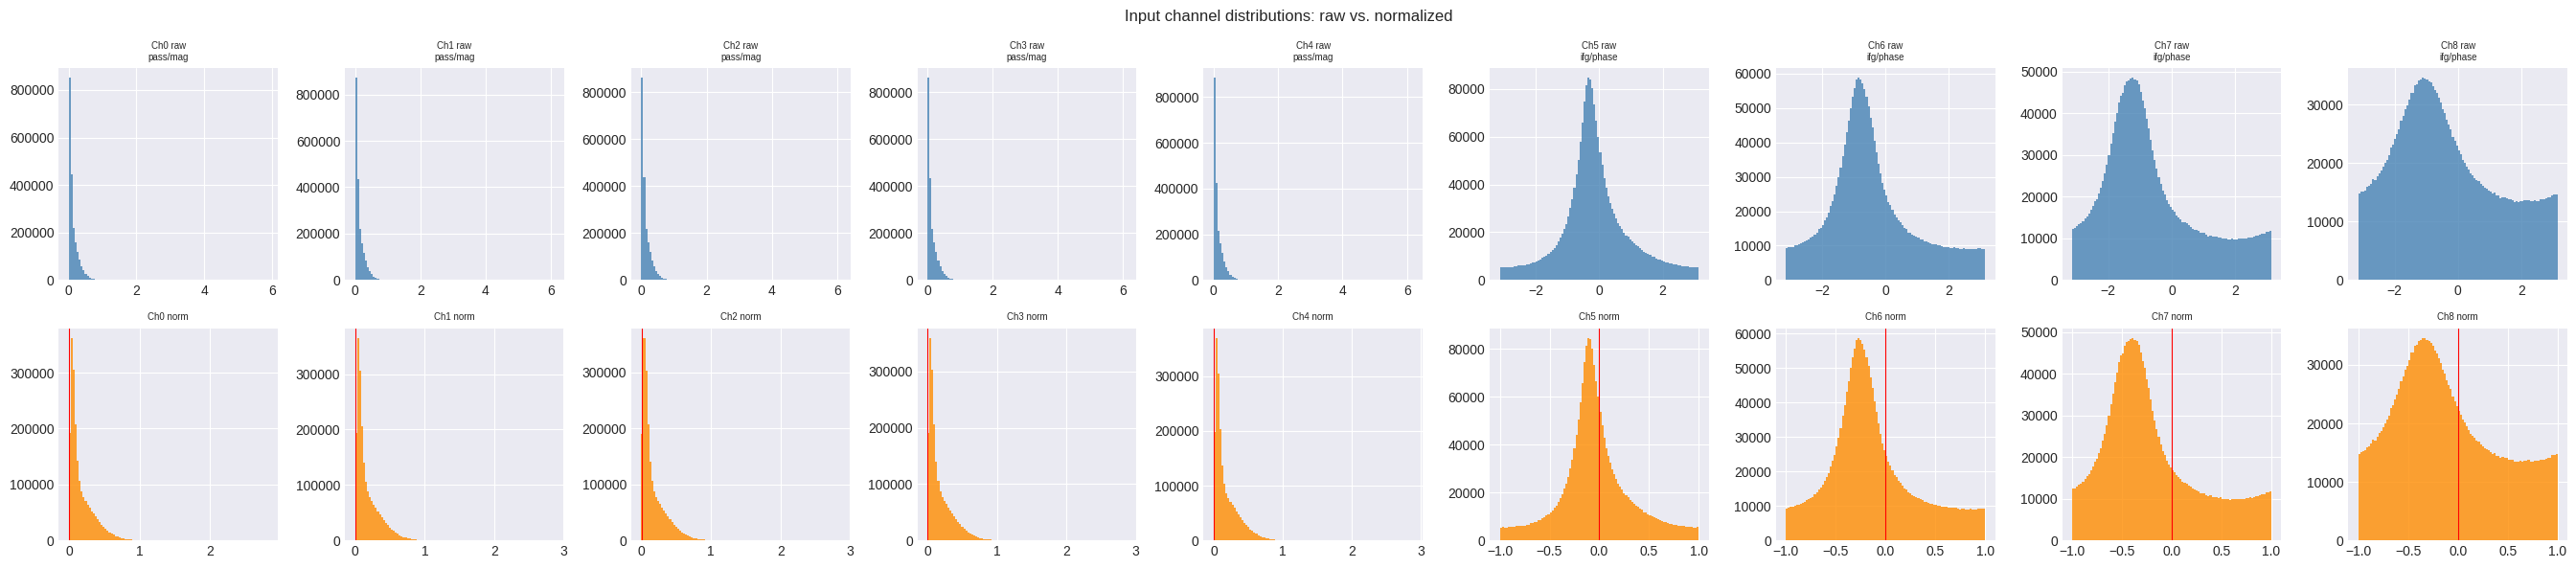

In [11]:
n_ch = all_x.shape[1]
fig, axes = plt.subplots(2, n_ch, figsize=(max(3*n_ch, 12), 6))
fig.suptitle("Input channel distributions: raw vs. normalized", fontsize=12)

all_x_raw = np.stack([dataset_raw[i][0] for i in idxs], axis=0)

for ch in range(n_ch):
    raw_vals  = all_x_raw[:, ch].ravel()
    norm_vals = all_x[:, ch].ravel()
    name      = stats.names[ch]

    axes[0, ch].hist(raw_vals,  bins=100, color="steelblue", alpha=0.8)
    axes[0, ch].set_title(f"Ch{ch} raw\n{name}", fontsize=7)

    axes[1, ch].hist(norm_vals, bins=100, color="darkorange", alpha=0.8)
    axes[1, ch].set_title(f"Ch{ch} norm", fontsize=7)
    axes[1, ch].axvline(0, color='red', linewidth=0.8)

plt.tight_layout()
plt.show()